<a href="https://colab.research.google.com/github/minaa9/mon-portfolio/blob/main/notebook_Amina.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyse de score éditorial anime

L'objectif de ce notebook est de nettoyer un dataset et de proposer un score  pour identifier les animés à forte valeur éditoriale

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


## Importation des librairies

Les librairies pandas, matplotlib  sont utilisées pour la
manipulation des tableaux de  données et créer des graphique

In [8]:
df = pd.read_csv("animes (2).csv")
df.head()

,Anime,Genre_Tags,Source,Nb_Episodes,Status,Studio,Date_Pub,Note_Globale,Note_Meilleur_Ep,Meilleur_Ep_Titre,Comm_Meilleur_Ep,Note_Pire_Ep,Pire_Ep_Titre,Comm_Pire_Ep,Comm_Saison_1,Comm_Saison_2,Comm_Saison_3
0,Naruto,Action / Shonen,Manga,220,Fini,Studio Pierrot,2002-10-03,8.4,9.6,Ep 133: Le cri des larmes,Animation fluide et combat viscéral incroyable.,5.8,Ep 26: Journal de Konoha (Recap),"Remplissage inutile, à sauter.","Arc Zabuza très émouvant, bases solides.",Examen Chuunin introduit une tension sombre.,Combat Lee vs Gaara légendaire.
1,Trigun,Sci-Fi / Action,Manga,26,Fini,Madhouse,1998-04-01,8.2,9.1,Ep 24: Le péché (Sin),"Conclusion tragique de l'arc Wolfwood, émotion...",6.5,Ep 13: Vash the Stampede (Recap),Résumé de mi-saison qui casse le rythme.,"Début western comique, Vash joue l'idiot.",Virage dramatique sombre avec les Gung-Ho Guns.,Révélations philosophiques sur le passé et Kni...
2,Dragon Ball Z,Action / Shonen,Manga,291,Fini,Toei Animation,1989-04-26,8.7,9.4,Ep 237: Le sacrifice d'un père,"Rédemption ultime de Vegeta, sommet émotionnel.",5.9,Ep 39: Amis ou ennemis (Fake Namek),"Filler ennuyeux sur une fausse planète, inutile.",Introduction des Saiyans et codes du Shonen po...,Aventure spatiale et tension tactique sur Namek.,"Transformation Super Saiyan iconique, combat é..."
3,Fullmetal Alchemist: Brotherhood,Aventure / Military,Manga,64,Fini,Bones,2009-04-05,9.1,9.6,Ep 63: De l'autre côté de la porte,"Sacrifice thématique parfait, conclusion magis...",6.3,Ep 27: Intermède (Recap),Episode récapitulatif cassant le rythme.,"Début effréné, traumatisme Nina Tucker marquant.",Complot politique et Mustang brille contre Lust.,"Ambiance militaire froide à Briggs, tension mo..."
4,Cowboy Bebop,Sci-Fi / Noir,Original,26,Fini,Sunrise,1998-04-03,8.8,9.7,Ep 26: The Real Folk Blues Pt.2,Fin poétique et iconique. Bang.,7.2,Ep 23: Boogie Woogie Feng Shui,Intrigue faible et rythme un peu mou.,Formation de l'équipe et choc visuel à l'église.,Exploration mélancolique du passé (Jupiter Jazz).,Confrontation fatale avec le Syndicat et Vicious.


##Charger le fichier cvs
charger le ficher anime.cvs pour le nottoyer et avoir le score éditoriel finale



## Exploration des données

Je vais faire apparaitre les premières lignes du dataset pour comprendre
sa structure

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73 entries, 0 to 72
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Anime              73 non-null     object 
 1   Genre_Tags         73 non-null     object 
 2   Source             73 non-null     object 
 3   Nb_Episodes        73 non-null     int64  
 4   Status             73 non-null     object 
 5   Studio             73 non-null     object 
 6   Date_Pub           73 non-null     object 
 7   Note_Globale       73 non-null     float64
 8   Note_Meilleur_Ep   73 non-null     float64
 9   Meilleur_Ep_Titre  73 non-null     object 
 10  Comm_Meilleur_Ep   73 non-null     object 
 11  Note_Pire_Ep       73 non-null     float64
 12  Pire_Ep_Titre      73 non-null     object 
 13  Comm_Pire_Ep       73 non-null     object 
 14  Comm_Saison_1      73 non-null     object 
 15  Comm_Saison_2      73 non-null     object 
 16  Comm_Saison_3      63 non-nu

## Comprendre le  dataset

La fonction df.info() permet lister les colonnes, les lignes ,les valeurs manquantes ce qui permet d’obtenir une vue globale du dataset

In [10]:
df.describe()

,Nb_Episodes,Note_Globale,Note_Meilleur_Ep,Note_Pire_Ep
count,73.000000,73.000000,73.000000,73.000000
mean,80.863014,8.297260,9.308219,6.745205
std,149.953263,0.505243,0.449924,1.317093
min,3.000000,6.000000,8.200000,0.000000
25%,24.000000,8.100000,9.100000,6.300000
50%,32.000000,8.400000,9.400000,7.200000
75%,74.000000,8.600000,9.700000,7.500000
max,1090.000000,9.300000,9.900000,8.400000


cette fonction permet de calculer les statistique principales automatiquement donc observer la distribution des notes et identifier des valeures aberrantes

In [11]:
text_columns = ["Anime", "Studio", "Genre_Tags", "Status", "Source"]

for col in text_columns:
    df[col] = df[col].astype(str).str.lower()

##Uniformisation du texte
Pour mettre  les données textuelles en un seul  uniforme et éviter les incohérences,les colonnes de type texte sont mises en minuscules.

In [23]:
df = df.dropna()


##Supprimer les valeurs manquantes
Les lignes contenant des valeurs manquantes ont été supprimées afin
d’assurer la cohérence de l’analyse.





In [24]:
df["Status"].value_counts()


,count
Status,
fini,43
en cours,17
en pause,3


In [20]:
df = df.sort_values(by="Note_Globale", ascending=False)


##trier les données
Les données ont été triées par score décroissant.

In [31]:
import seaborn as sns


c'est une commande dans une bibliothèque Python qui rajoute la touche esthétique pour créer des visualisations de données statistiques élégantes

Text(0, 0.5, "Nombre d'animes")

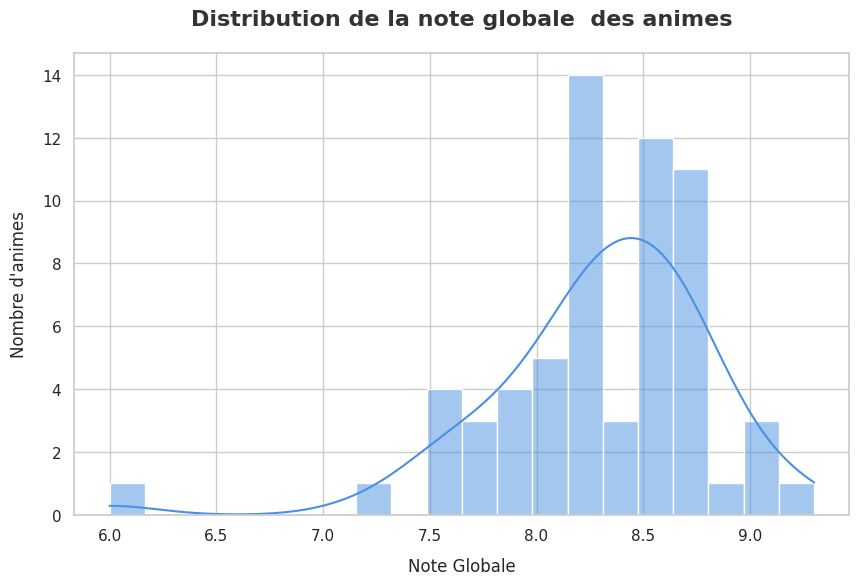

In [59]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

ax = sns.histplot(df["Note_Globale"], bins=20, color="#4A90E2",
edgecolor="white", kde=True)

plt.title("Distribution de la note globale  des animes", fontsize=16, fontweight='bold',
pad=20, color="#333333")
plt.xlabel("Note Globale", fontsize=12, labelpad=10)
plt.ylabel("Nombre d'animes", fontsize=12, labelpad=10)




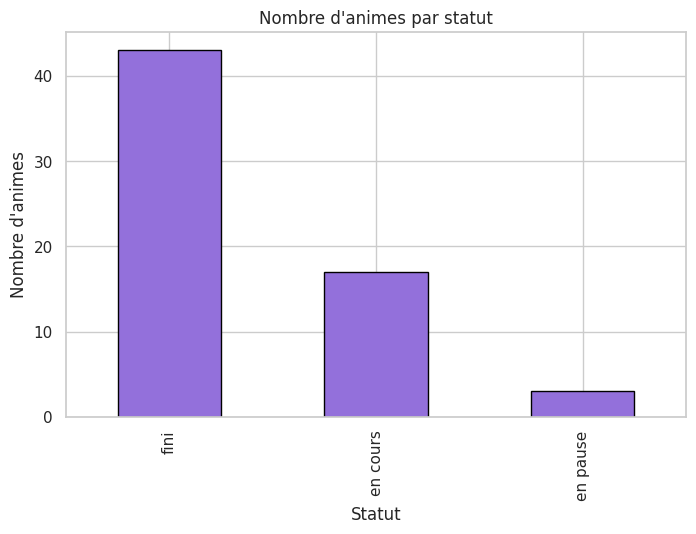

In [37]:
status_counts = df["Status"].value_counts()

plt.figure(figsize=(8,5))
status_counts.plot(kind="bar", color="#9370DB", edgecolor="black")
plt.title("Nombre d'animes par statut")
plt.xlabel("Statut")
plt.ylabel("Nombre d'animes")
plt.show()

In [40]:
long_animes = df[df["Nb_Episodes"] > 24]
long_animes.head()

,Anime,Genre_Tags,Source,Nb_Episodes,Status,Studio,Date_Pub,Note_Globale,Note_Meilleur_Ep,Meilleur_Ep_Titre,Comm_Meilleur_Ep,Note_Pire_Ep,Pire_Ep_Titre,Comm_Pire_Ep,Comm_Saison_1,Comm_Saison_2,Comm_Saison_3
35,frieren: beyond journey's end,adventure / fantasy,manga,28,en cours,madhouse,2023-09-29,9.3,9.4,Ep 10: Frieren the Slayer,Démonstration de puissance calme et terrifiante.,7.3,Ep 22: Future Enemies,"Rythme un peu plus lent, transition vers l'exa...",Voyage mélancolique sur le temps qui passe et ...,"Production Madhouse sublime, ambiance 'comfy' ...",Les relations subtiles (Frieren/Fern/Stark) so...
3,fullmetal alchemist: brotherhood,aventure / military,manga,64,fini,bones,2009-04-05,9.1,9.6,Ep 63: De l'autre côté de la porte,"Sacrifice thématique parfait, conclusion magis...",6.3,Ep 27: Intermède (Recap),Episode récapitulatif cassant le rythme.,"Début effréné, traumatisme Nina Tucker marquant.",Complot politique et Mustang brille contre Lust.,"Ambiance militaire froide à Briggs, tension mo..."
19,hunter x hunter (2011),adventure / shonen,manga,148,fini,madhouse,2011-10-02,9.0,9.7,Ep 131: Colère x et x Lumière,La transformation de Gon. Animation et émotion...,5.9,Ep 13: Lettre x de x Gon (Recap),"Episode résumé très tôt dans la série, inutile.",Examen Hunter : Aventure pure et découverte de...,"Yorknew City : Ambiance noire, Kurapika vs la ...",Chimera Ant : L'arc le plus sombre et philosop...
44,monster,thriller / mystery,manga,74,fini,madhouse,2004-04-07,8.9,9.1,Ep 4: Night of Punishment,Tension insoutenable et écriture magistrale.,7.4,Ep 8: The Fugitive,"Rythme plus lent, mise en place des pièces.",Johan Liebert est le meilleur méchant de l'his...,Un thriller psychologique lent mais incroyable...,"Pas de pouvoirs, juste la noirceur de l'âme hu..."
4,cowboy bebop,sci-fi / noir,original,26,fini,sunrise,1998-04-03,8.8,9.7,Ep 26: The Real Folk Blues Pt.2,Fin poétique et iconique. Bang.,7.2,Ep 23: Boogie Woogie Feng Shui,Intrigue faible et rythme un peu mou.,Formation de l'équipe et choc visuel à l'église.,Exploration mélancolique du passé (Jupiter Jazz).,Confrontation fatale avec le Syndicat et Vicious.


## Filtrer les animes avec plus de 24 épisodes
sa permet de limiter les épisodes

Text(0, 0.5, "Nombre d'épisodes ")

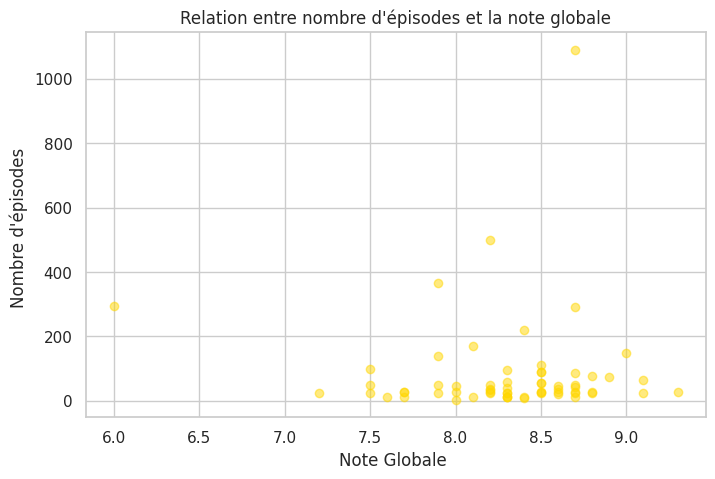

In [58]:
plt.figure(figsize=(8,5))
plt.scatter(df["Note_Globale"],df["Nb_Episodes"], color="#FFD700", alpha=0.5)
plt.title("Relation entre nombre d'épisodes et la note globale")
plt.xlabel("Note Globale ")
plt.ylabel("Nombre d'épisodes ")

plt.show()


##Nuage de points
C'est pour voir la relation entre le nombre d'épisodes et la note globale

In [54]:
correlation = df[["Nb_Episodes", "Note_Globale" ]].corr()
correlation

,Nb_Episodes,Note_Globale
Nb_Episodes,1.000000,-0.023335
Note_Globale,-0.023335,1.000000


##Mesurer la relation entre le nombre d'épisode et la note globale
on remarque que le nombre d'épisode inférieure à 1  donc c'est un lien parfait négatif
et pour la note globale est 1 donc c'est un lien parfait positif

Text(0.5, 1.0, 'Matrice de corrélation')

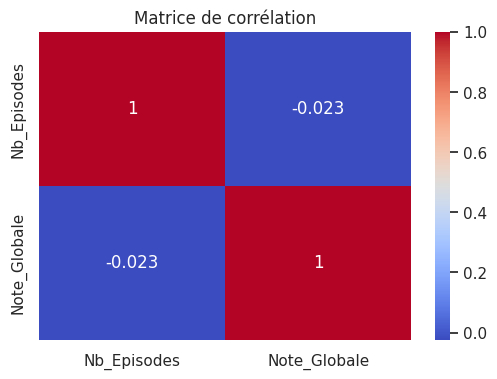

In [57]:
plt.figure(figsize=(6,4))
sns.heatmap(correlation, annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")


##Conclusion

Cette analyse a permis de nettoyer et d’explorer le dataset des animes.
Les données textuelles ont été uniformisées, les valeurs manquantes
supprimées et plusieurs visualisations ont été réalisées afin de mieux
comprendre la distribution la nombre d'episode , des statuts et la relation entre la note globale et le nombre d'épisode.